# Libraries



In [179]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statistics import mode



from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OrdinalEncoder
from sklearn.feature_selection import mutual_info_classif


import tensorflow as tf
import time


import torch
import torch.nn as nn
import torch.optim as optim

# Reading data

In [180]:
filepath = '/content/drive/MyDrive/ICT AIML/Datasets/adult_dataset.csv'
adult_df = pd.read_csv(filepath)
adult_df.head(2)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K


## EDA

In [181]:
adult_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [182]:
adult_df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,46400.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,46400.000000
mean,38.679116,1.896641e+05,10.078089,1079.067626,87.502314,40.448599
std,13.952954,1.056040e+05,2.570973,7452.019058,403.004552,12.646992
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,255.000000,1.490400e+06,16.000000,99999.000000,4356.000000,250.000000


In [183]:
adult_df.shape

(48842, 15)

In [184]:
adult_df['income'].unique()

array(['<=50K', '>50K', '<=50K.', '>50K.'], dtype=object)

##

## Plotting

In [185]:
num_cols = adult_df.select_dtypes(include=['int','float']).columns
cat_cols = adult_df.select_dtypes(include=['object','bool']).columns
num_cols


Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')

In [186]:
cat_cols

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object')

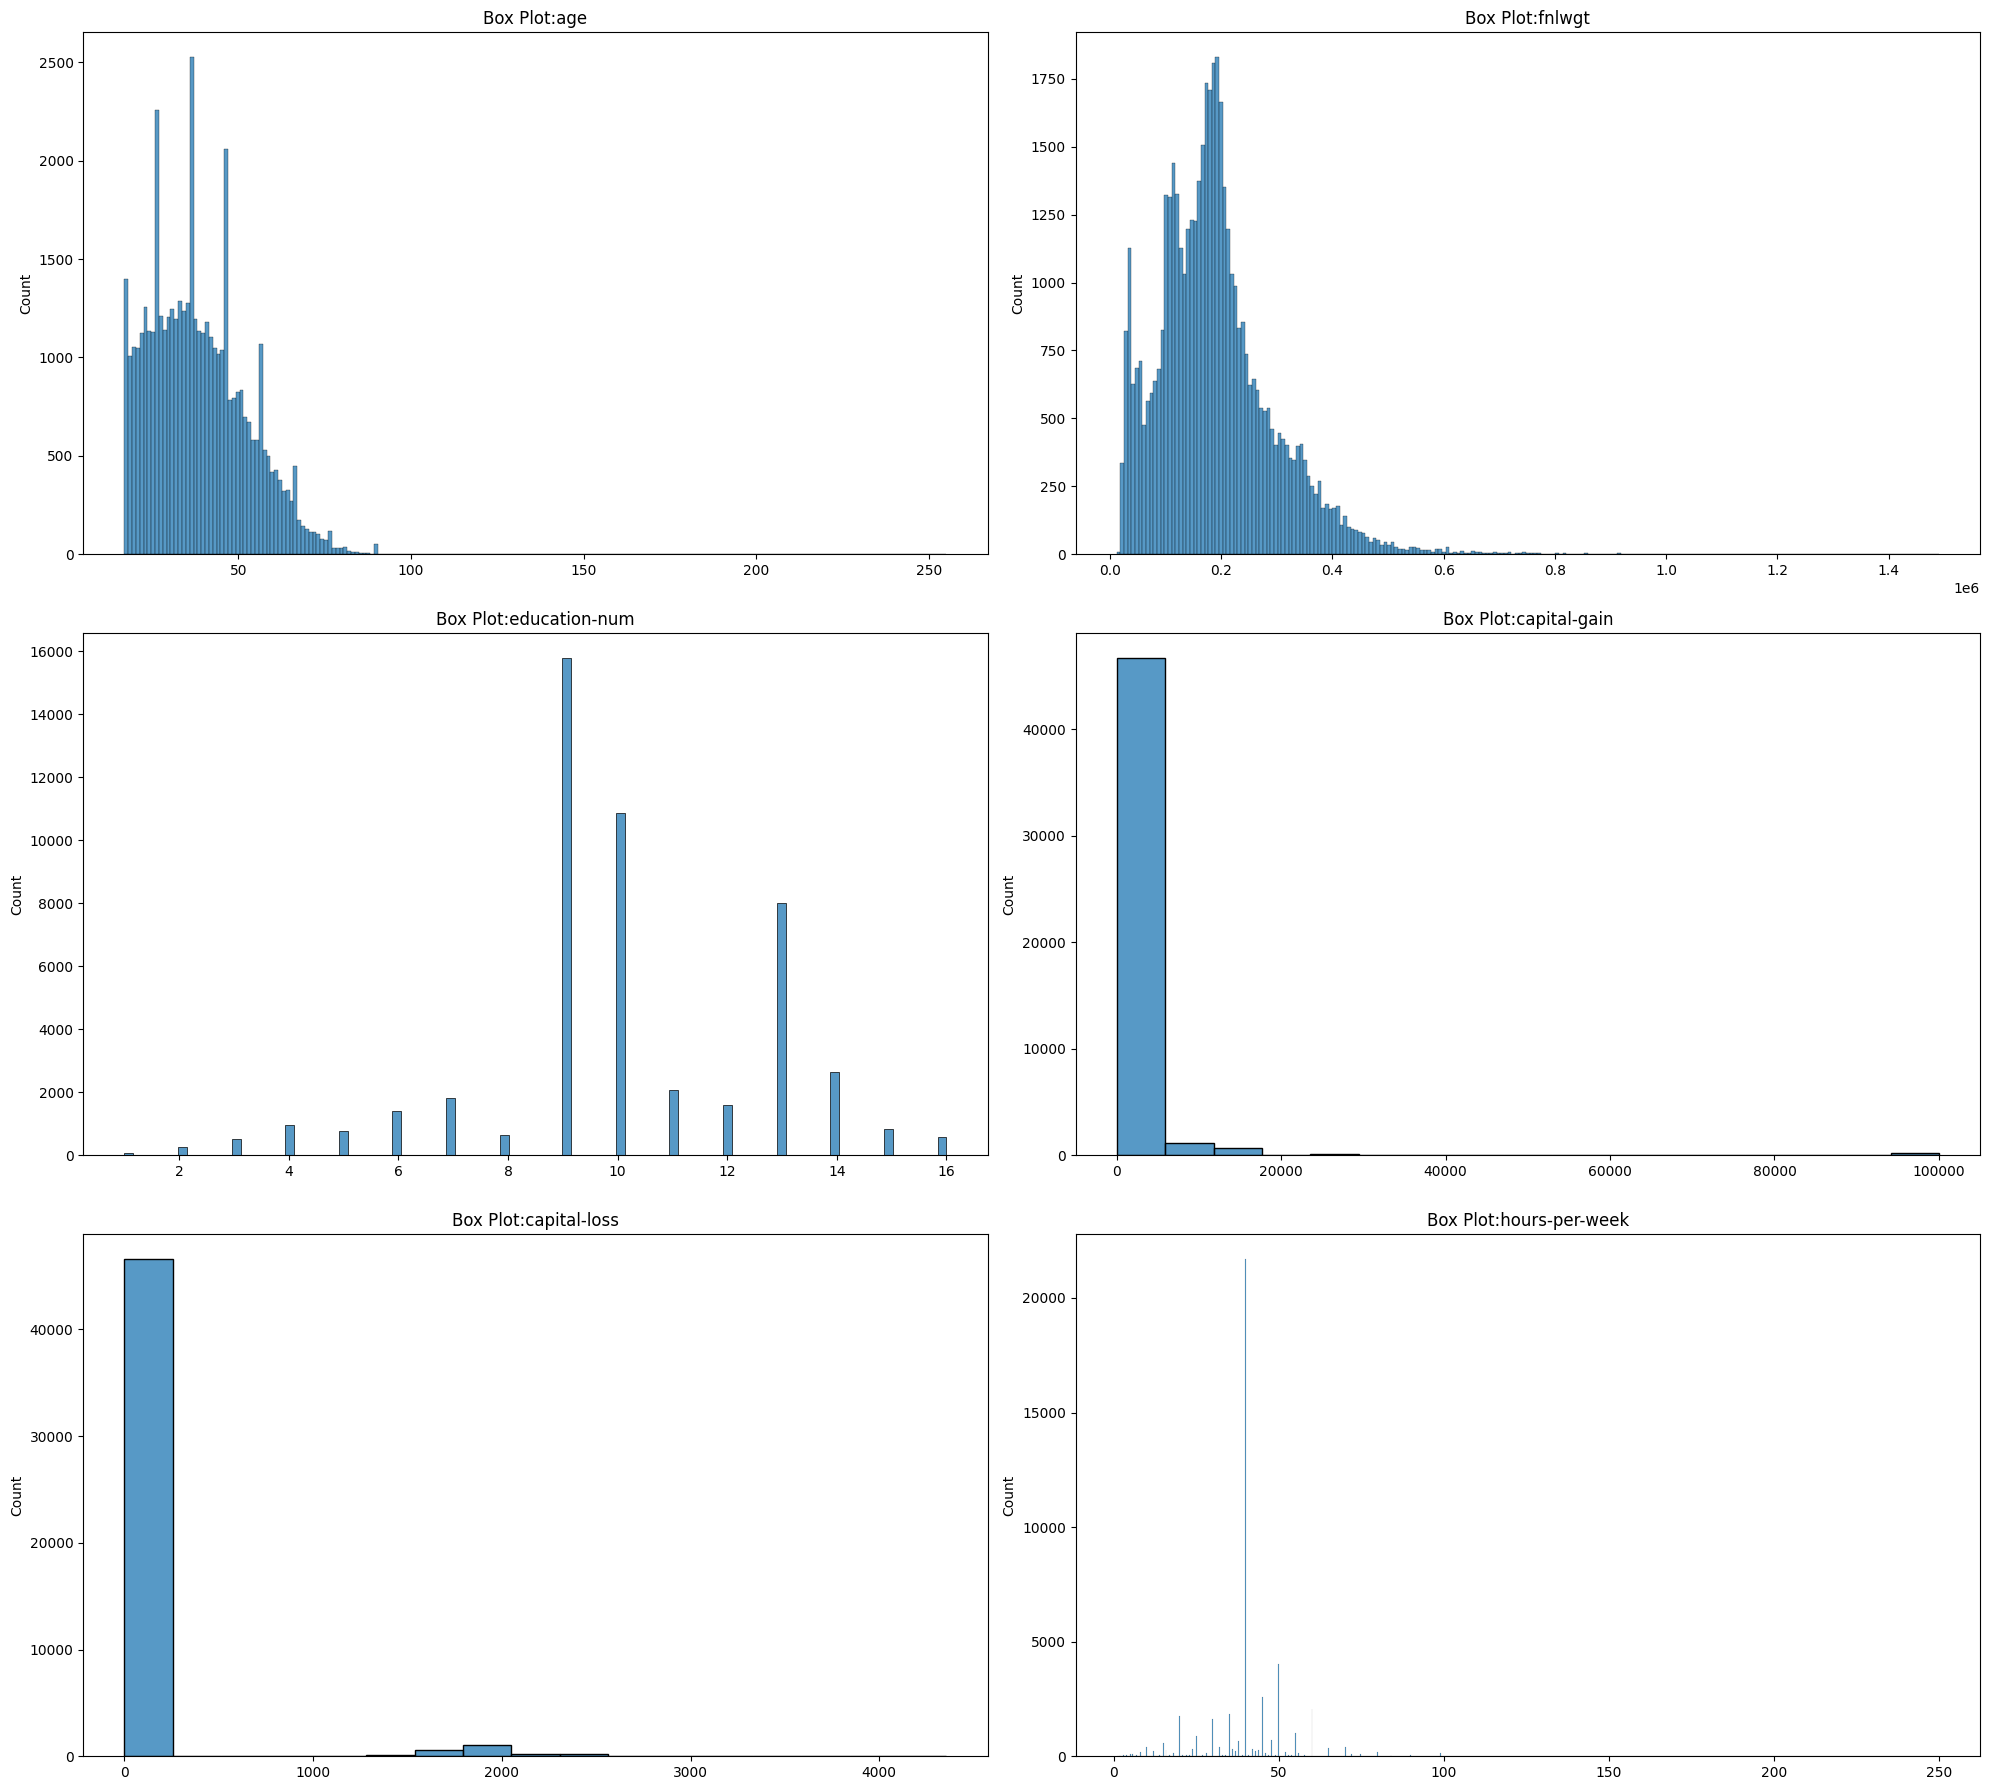

In [187]:
plt.figure(figsize=(20,18))

for i,col in enumerate(num_cols):
  plt.subplot(3,2,i+1)
  sns.histplot(adult_df[col])
  plt.title(f'Box Plot:{col}')
  plt.xlabel('')

plt.tight_layout()
plt.show()

## Correlation matrix

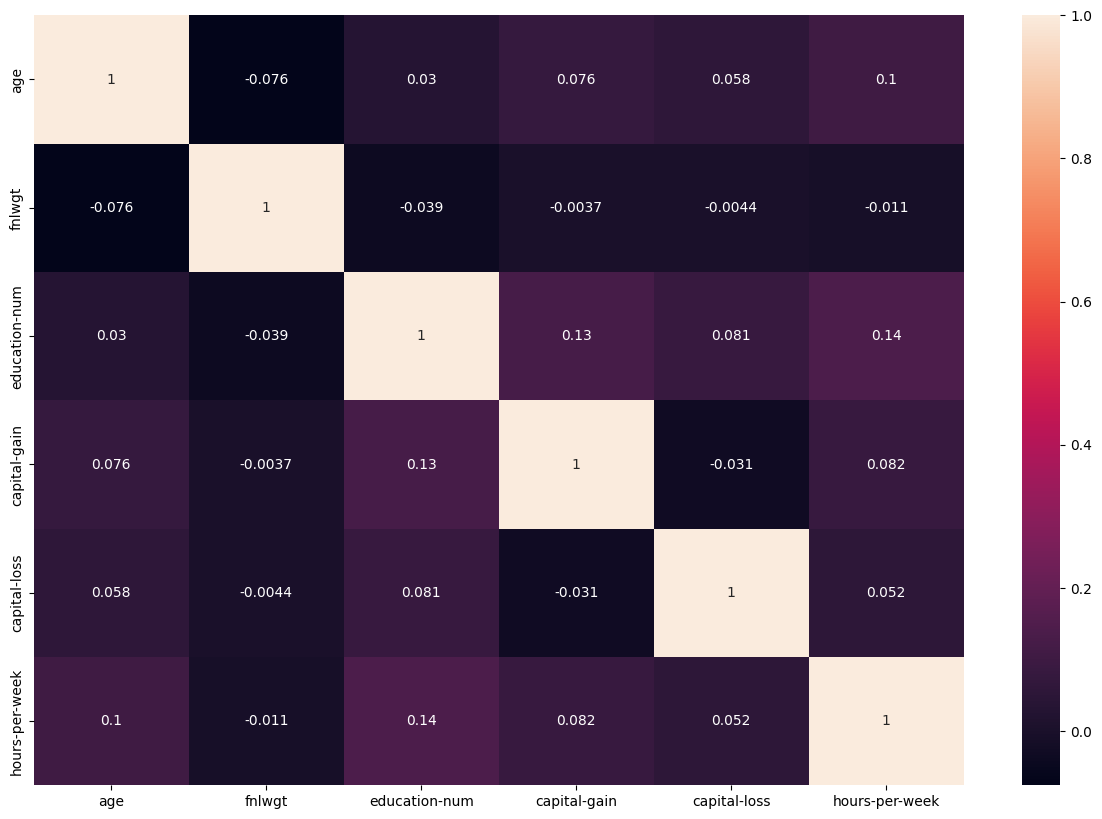

In [188]:

num_cols = adult_df.select_dtypes(include=['int','float']).columns
corr_mat = adult_df[num_cols].corr()
plt.figure(figsize = (15,10))
sns.heatmap(corr_mat,annot = True)
plt.show()

# Data preprocessing

## Missing Value handle

In [189]:
adult_df.isnull().sum()

,0
age,2442
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


In [190]:
adult_df['age'].fillna(adult_df['age'].median(),inplace=True)

/tmp/ipykernel_497/2889688602.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adult_df['age'].fillna(adult_df['age'].median(),inplace=True)


In [191]:
adult_df['workclass'].unique()

array(['State-gov', 'Self-emp-not-inc', 'Private', 'Federal-gov', nan,
       'Local-gov', '?', 'Self-emp-inc', 'Without-pay', 'Never-worked'],
      dtype=object)

In [192]:
adult_df['workclass'].replace('?', mode(adult_df['workclass']), inplace=True)


/tmp/ipykernel_497/931777568.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adult_df['workclass'].replace('?', mode(adult_df['workclass']), inplace=True)


In [193]:
adult_df['workclass'].unique()

array(['State-gov', 'Self-emp-not-inc', 'Private', 'Federal-gov', nan,
       'Local-gov', 'Self-emp-inc', 'Without-pay', 'Never-worked'],
      dtype=object)

In [194]:
adult_df['workclass'].fillna (mode(adult_df['workclass']),inplace = True)

/tmp/ipykernel_497/3310786248.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adult_df['workclass'].fillna (mode(adult_df['workclass']),inplace = True)


In [195]:
adult_df['occupation'] = adult_df['occupation'].replace('?', np.nan)

In [196]:
adult_df['occupation'].fillna(mode(adult_df['occupation']),inplace = True)

/tmp/ipykernel_497/808062345.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adult_df['occupation'].fillna(mode(adult_df['occupation']),inplace = True)


In [197]:
adult_df['hours-per-week'].fillna(adult_df['hours-per-week'].mean(),inplace=True)


/tmp/ipykernel_497/3071846712.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adult_df['hours-per-week'].fillna(adult_df['hours-per-week'].mean(),inplace=True)


In [198]:
adult_df['native-country'].fillna(mode(adult_df['native-country']),inplace = True)

/tmp/ipykernel_497/3662169867.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adult_df['native-country'].fillna(mode(adult_df['native-country']),inplace = True)


In [199]:
adult_df.shape

(48842, 15)

## Duplicates Removal

In [200]:
adult_df.duplicated().sum()

np.int64(22)

In [201]:
adult_df.drop_duplicates(inplace=True)

In [202]:
adult_df.shape

(48820, 15)

# Outlier Handling

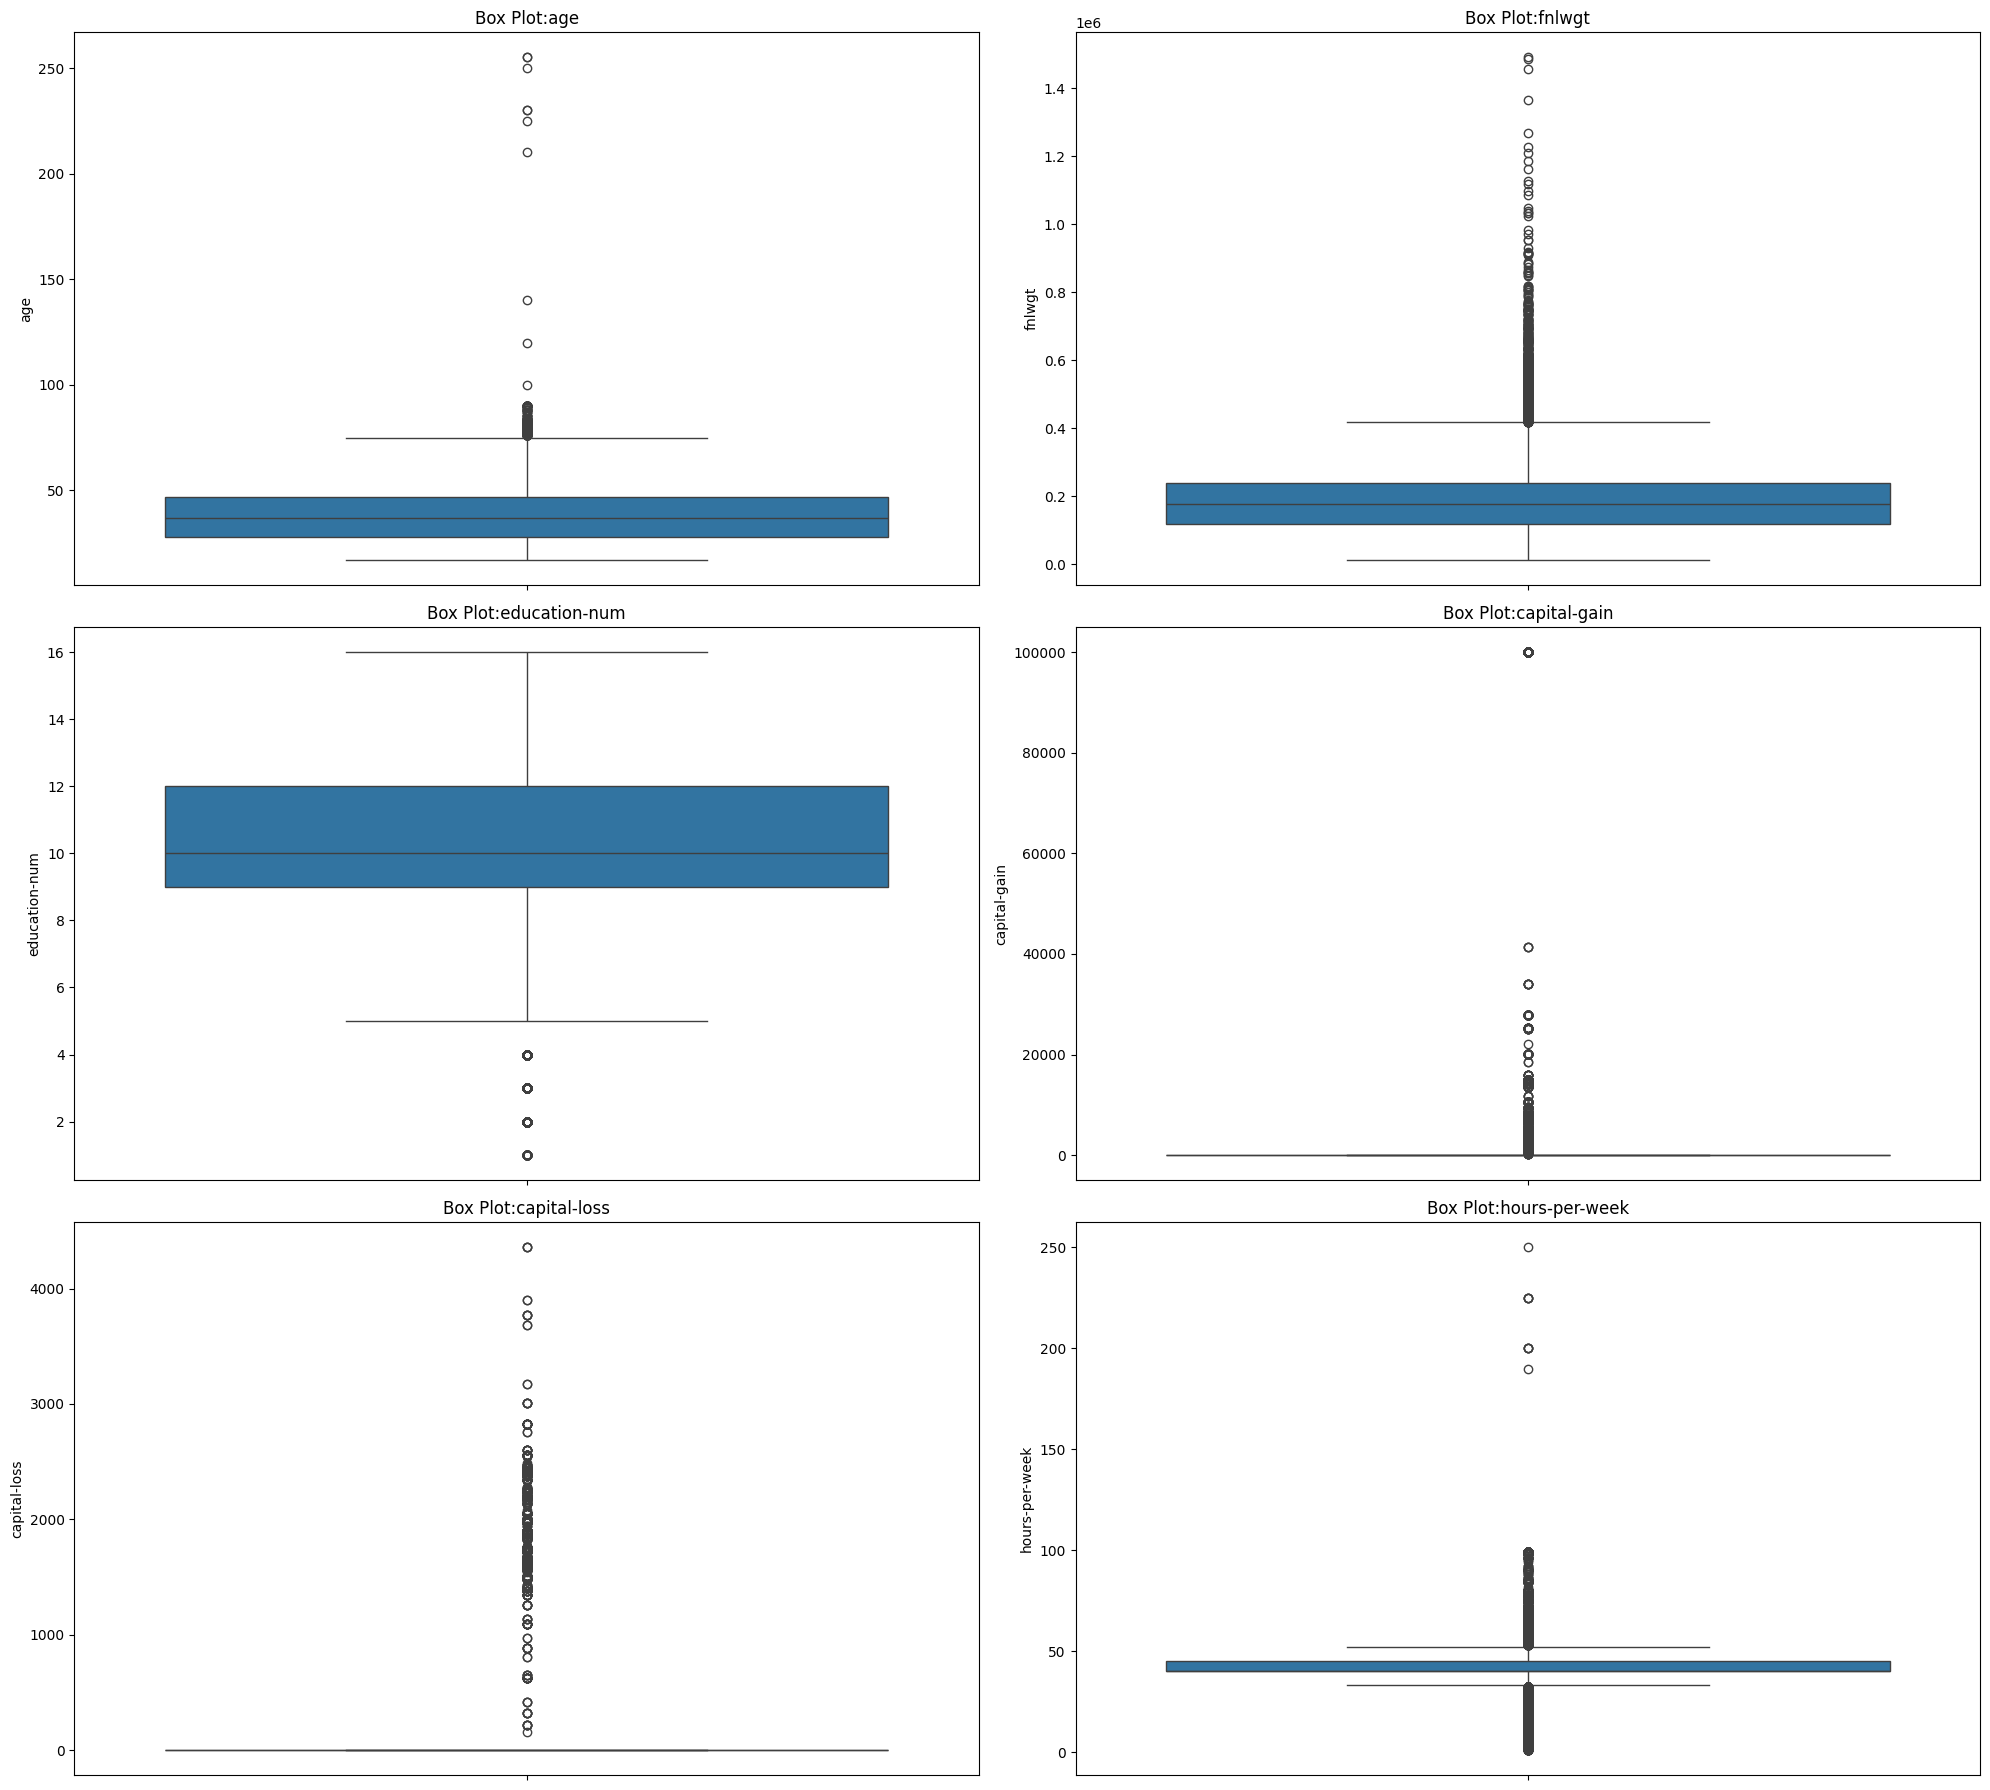

In [203]:
# Before Outlier Handling
plt.figure(figsize=(20,18))

for i,col in enumerate(num_cols):
  plt.subplot(3,2,i+1)
  sns.boxplot(adult_df[col])
  plt.title(f'Box Plot:{col}')
plt.tight_layout()
plt.show()

In [204]:
outlier_cols = ['age','fnlwgt','education-num','capital-gain','capital-loss','hours-per-week']

for i in outlier_cols:
  Q1 = adult_df[i].quantile(0.25)
  Q3 = adult_df[i].quantile(0.75)

  IQR = Q3-Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers = adult_df[(adult_df[i] < lower_bound) | (adult_df[i] > upper_bound ) ]
  print(f"{i} : {len(outliers)} outliers")
  adult_df[i] = adult_df[i].clip(lower = lower_bound, upper = upper_bound)

age : 363 outliers
fnlwgt : 1453 outliers
education-num : 1790 outliers
capital-gain : 4035 outliers
capital-loss : 2282 outliers
hours-per-week : 12833 outliers


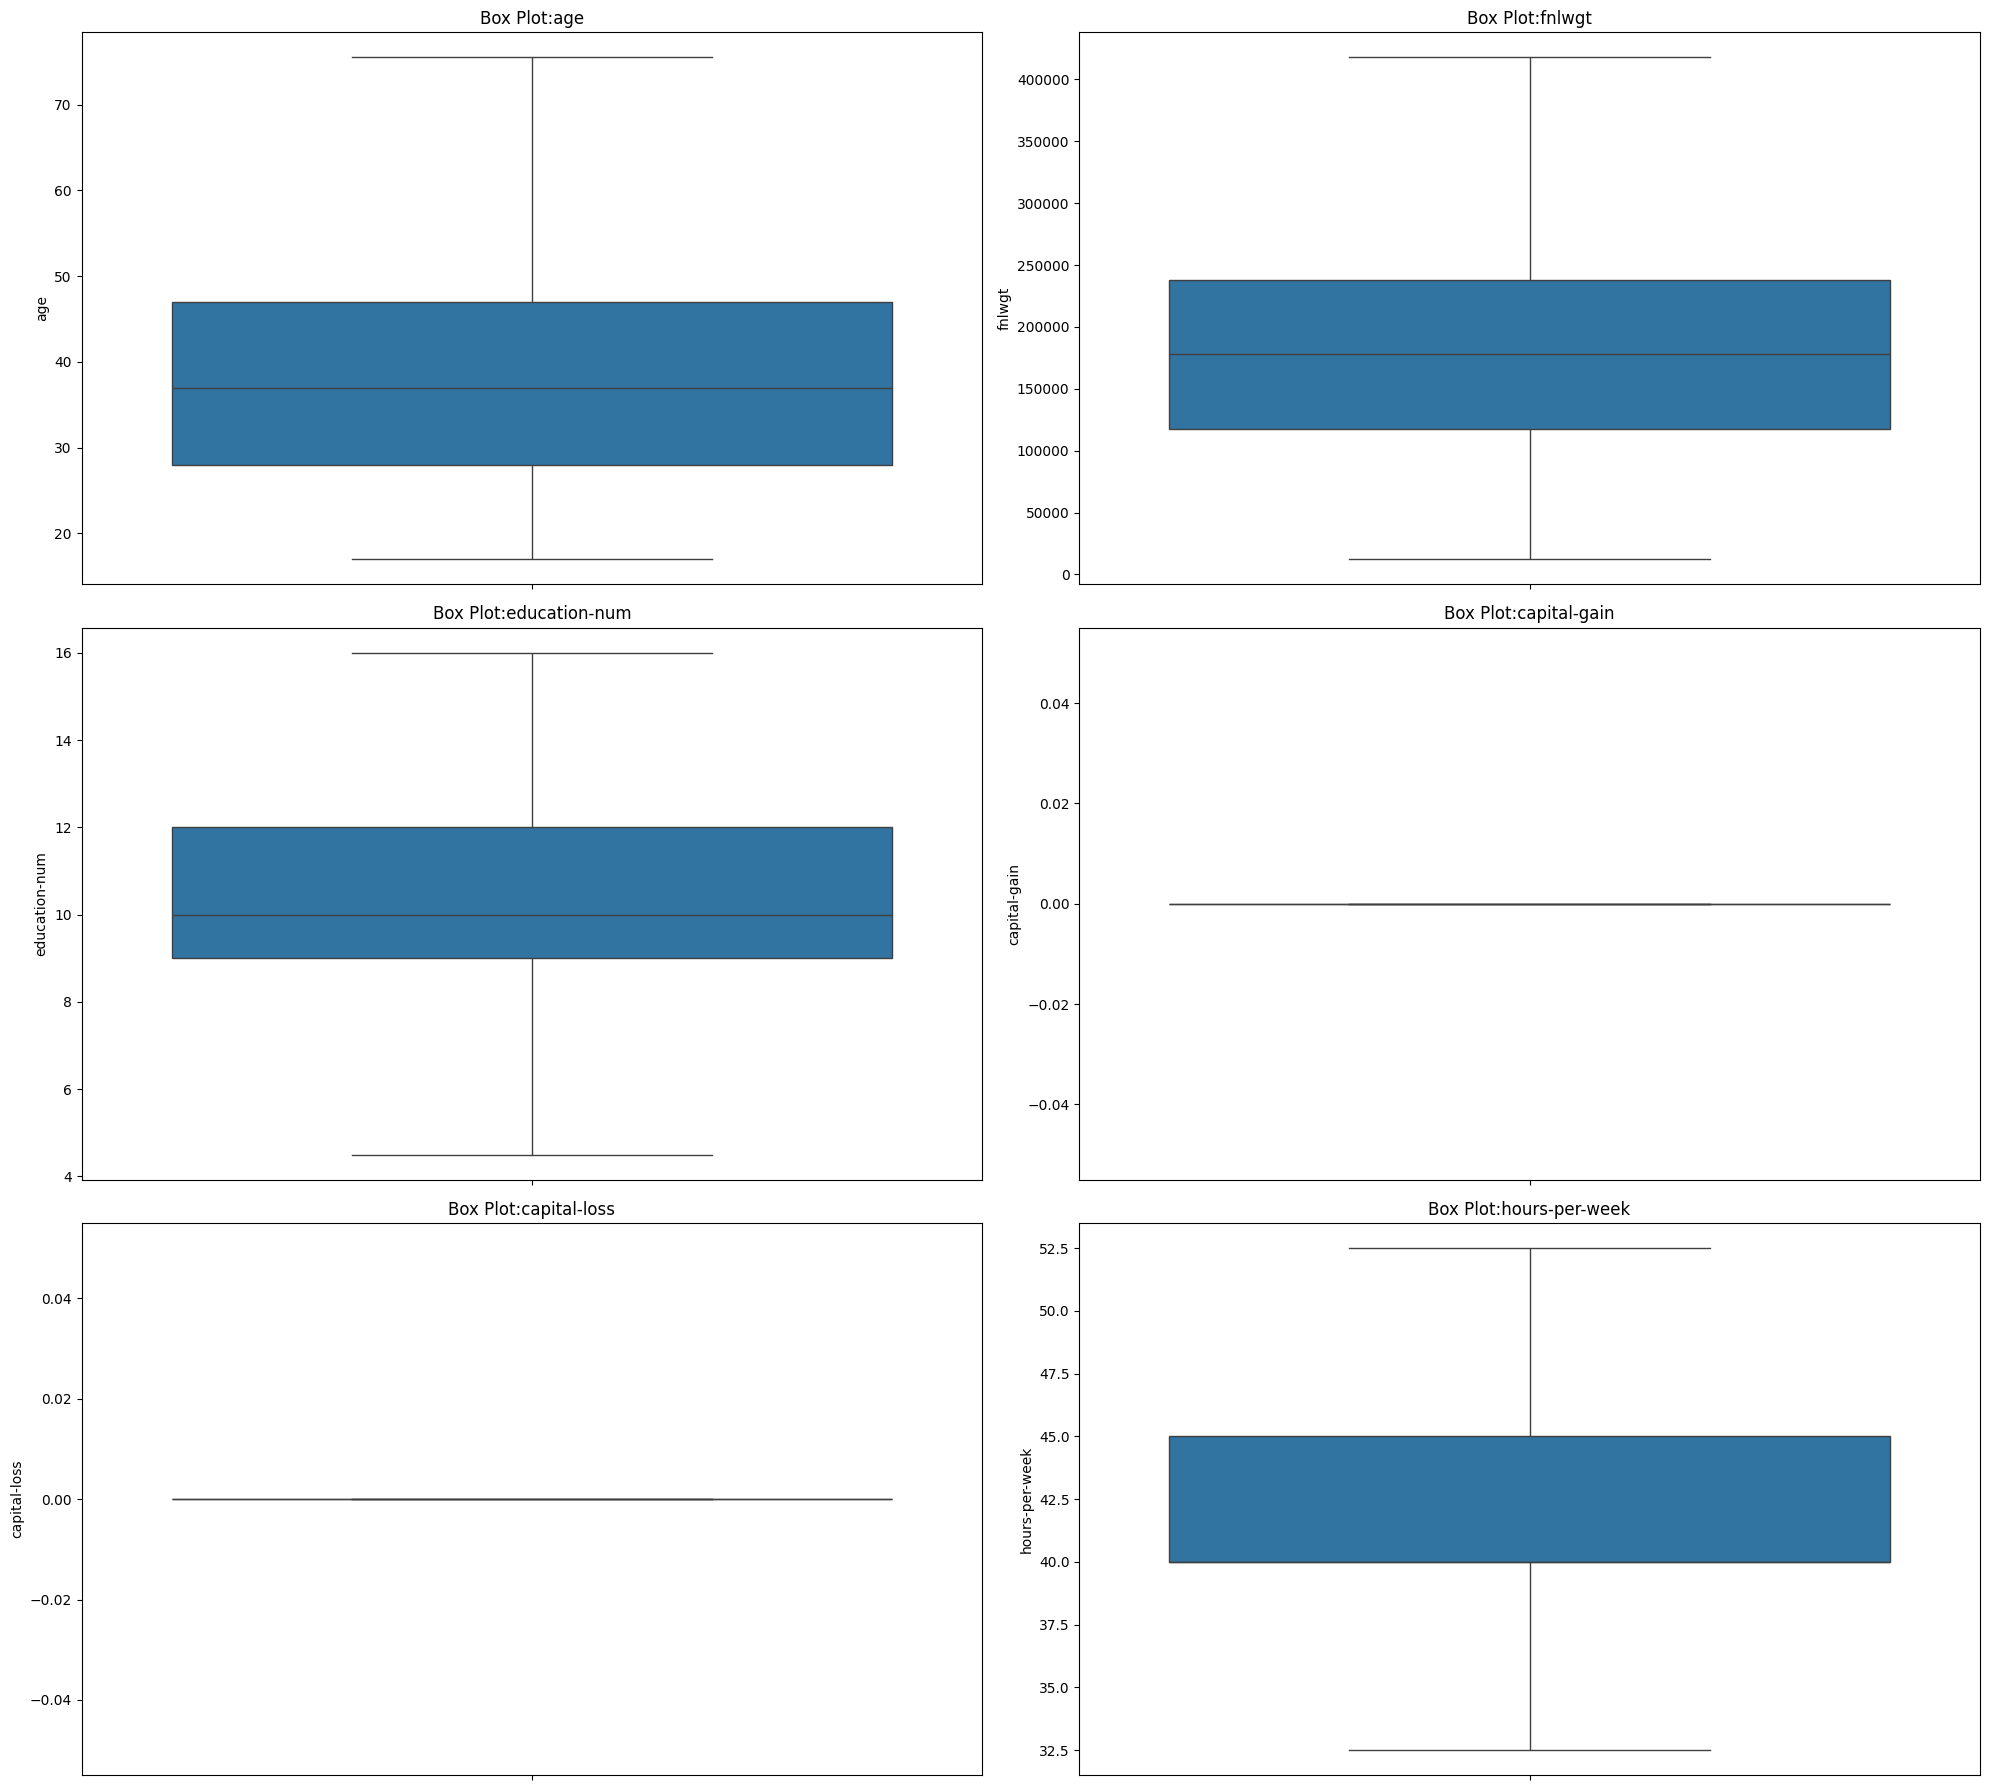

In [205]:
# After Outlier Handling
plt.figure(figsize=(20,18))

for i,col in enumerate(num_cols):
  plt.subplot(3,2,i+1)
  sns.boxplot(adult_df[col])
  plt.title(f'Box Plot:{col}')

plt.tight_layout()
plt.show()

# Data Transformations

## Encoding

In [206]:
cat_cols = adult_df.select_dtypes(include=['object']).columns
cat_cols

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object')

In [207]:
adult_df['income'].unique()

array(['<=50K', '>50K', '<=50K.', '>50K.'], dtype=object)

In [208]:
adult_df['income'] = adult_df['income'].str.replace('.', '', regex=False)
adult_df['income'].unique()

array(['<=50K', '>50K'], dtype=object)

###  Label Encoding: Income and Sex

In [209]:
adult_df.head(2)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516.0,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,32.5,United-States,<=50K


In [210]:
label_enc = LabelEncoder()

adult_df['income'] = label_enc.fit_transform(adult_df['income'])
adult_df['sex'] = label_enc.fit_transform(adult_df['sex'])

In [211]:
adult_df.head(2)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516.0,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,1,0,0,40.0,United-States,0
1,50.0,Self-emp-not-inc,83311.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,1,0,0,32.5,United-States,0


In [212]:
adult_df.shape

(48820, 15)

### One Hot Encoding: Marital Status, Occupation, Relation, Native country, Race, Workclass

In [213]:
adult_df['marital-status'].unique()

array(['Never-married', 'Married-civ-spouse', 'Divorced',
       'Married-spouse-absent', 'Separated', 'Married-AF-spouse',
       'Widowed'], dtype=object)

In [214]:
adult_df['occupation'].unique()

array(['Adm-clerical', 'Exec-managerial', 'Handlers-cleaners',
       'Prof-specialty', 'Other-service', 'Sales', 'Craft-repair',
       'Transport-moving', 'Farming-fishing', 'Machine-op-inspct',
       'Tech-support', 'Protective-serv', 'Armed-Forces',
       'Priv-house-serv'], dtype=object)

In [215]:
adult_df['relationship'].unique()

array(['Not-in-family', 'Husband', 'Wife', 'Own-child', 'Unmarried',
       'Other-relative'], dtype=object)

In [216]:
adult_df['native-country'].unique()

array(['United-States', 'Cuba', 'Jamaica', 'India', '?', 'Mexico',
       'South', 'Puerto-Rico', 'Honduras', 'England', 'Germany', 'Iran',
       'Philippines', 'Italy', 'Columbia', 'Cambodia', 'Thailand',
       'Canada', 'Ecuador', 'Laos', 'Taiwan', 'Haiti', 'Portugal',
       'Dominican-Republic', 'El-Salvador', 'Poland', 'France',
       'Guatemala', 'China', 'Japan', 'Yugoslavia', 'Peru',
       'Outlying-US(Guam-USVI-etc)', 'Scotland', 'Trinadad&Tobago',
       'Greece', 'Nicaragua', 'Vietnam', 'Hong', 'Ireland', 'Hungary',
       'Holand-Netherlands'], dtype=object)

In [217]:
adult_df = pd.get_dummies(adult_df, columns=['marital-status','occupation','relationship','workclass'], drop_first=True)


In [218]:
adult_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48820 entries, 0 to 48841
Data columns (total 42 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   48820 non-null  float64
 1   fnlwgt                                48820 non-null  float64
 2   education                             48820 non-null  object 
 3   education-num                         48820 non-null  float64
 4   race                                  48820 non-null  object 
 5   sex                                   48820 non-null  int64  
 6   capital-gain                          48820 non-null  int64  
 7   capital-loss                          48820 non-null  int64  
 8   hours-per-week                        48820 non-null  float64
 9   native-country                        48820 non-null  object 
 10  income                                48820 non-null  int64  
 11  marital-status_Marri

In [219]:
adult_df.shape

(48820, 42)

### Ordinal Encoding

In [220]:
adult_df['education'].unique()

array(['Bachelors', 'HS-grad', '11th', 'Masters', '9th', 'Some-college',
       'Assoc-acdm', 'Assoc-voc', '7th-8th', 'Doctorate', 'Prof-school',
       '5th-6th', '10th', '1st-4th', 'Preschool', '12th'], dtype=object)

In [221]:
adult_df.head(2)

,age,fnlwgt,education,education-num,race,sex,capital-gain,capital-loss,hours-per-week,native-country,...,relationship_Own-child,relationship_Unmarried,relationship_Wife,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay
0,39.0,77516.0,Bachelors,13.0,White,1,0,0,40.0,United-States,...,False,False,False,False,False,False,False,False,True,False
1,50.0,83311.0,Bachelors,13.0,White,1,0,0,32.5,United-States,...,False,False,False,False,False,False,False,True,False,False


In [222]:
# OrdinalEncoder with the specified category order
edu_order = [['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th', 'HS-grad', 'Some-college', 'Assoc-voc', 'Assoc-acdm',
                    'Bachelors', 'Masters', 'Prof-school', 'Doctorate']]

ordinal_encoder = OrdinalEncoder(categories=edu_order)

# Apply Ordinal Encoding to the education column
adult_df[['education']] = ordinal_encoder.fit_transform(adult_df[['education']])

In [223]:
adult_df.head(2)

,age,fnlwgt,education,education-num,race,sex,capital-gain,capital-loss,hours-per-week,native-country,...,relationship_Own-child,relationship_Unmarried,relationship_Wife,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay
0,39.0,77516.0,12.0,13.0,White,1,0,0,40.0,United-States,...,False,False,False,False,False,False,False,False,True,False
1,50.0,83311.0,12.0,13.0,White,1,0,0,32.5,United-States,...,False,False,False,False,False,False,False,True,False,False


# Remove Irrelevant Information

In [224]:
adult_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48820 entries, 0 to 48841
Data columns (total 42 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   48820 non-null  float64
 1   fnlwgt                                48820 non-null  float64
 2   education                             48820 non-null  float64
 3   education-num                         48820 non-null  float64
 4   race                                  48820 non-null  object 
 5   sex                                   48820 non-null  int64  
 6   capital-gain                          48820 non-null  int64  
 7   capital-loss                          48820 non-null  int64  
 8   hours-per-week                        48820 non-null  float64
 9   native-country                        48820 non-null  object 
 10  income                                48820 non-null  int64  
 11  marital-status_Marri

In [225]:
adult_df['native-country'].value_counts()

,count
native-country,
United-States,44310
Mexico,905
?,555
Philippines,282
Germany,194
Puerto-Rico,175
Canada,170
El-Salvador,147
India,143


In [226]:
## Majority of the native-country is US. So it doesn't give any pattern

In [227]:
adult_df.drop(columns=['race','education-num','native-country'],inplace=True)

In [228]:
adult_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48820 entries, 0 to 48841
Data columns (total 39 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   48820 non-null  float64
 1   fnlwgt                                48820 non-null  float64
 2   education                             48820 non-null  float64
 3   sex                                   48820 non-null  int64  
 4   capital-gain                          48820 non-null  int64  
 5   capital-loss                          48820 non-null  int64  
 6   hours-per-week                        48820 non-null  float64
 7   income                                48820 non-null  int64  
 8   marital-status_Married-AF-spouse      48820 non-null  bool   
 9   marital-status_Married-civ-spouse     48820 non-null  bool   
 10  marital-status_Married-spouse-absent  48820 non-null  bool   
 11  marital-status_Never

# Scaling

In [229]:
skewed_cols = adult_df.select_dtypes(include=['int','float']).columns
skewed_cols

Index(['age', 'fnlwgt', 'education', 'sex', 'capital-gain', 'capital-loss',
       'hours-per-week', 'income'],
      dtype='object')

### Min Max Scaling

In [230]:
adult_df.head(3)

,age,fnlwgt,education,sex,capital-gain,capital-loss,hours-per-week,income,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,...,relationship_Own-child,relationship_Unmarried,relationship_Wife,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay
0,39.0,77516.0,12.0,1,0,0,40.0,0,False,False,...,False,False,False,False,False,False,False,False,True,False
1,50.0,83311.0,12.0,1,0,0,32.5,0,False,True,...,False,False,False,False,False,False,False,True,False,False
2,38.0,215646.0,8.0,1,0,0,40.0,0,False,False,...,False,False,False,False,False,True,False,False,False,False


In [231]:
minmax = MinMaxScaler()
adult_df[skewed_cols] = minmax.fit_transform(adult_df[skewed_cols])


In [232]:
adult_df.head()

,age,fnlwgt,education,sex,capital-gain,capital-loss,hours-per-week,income,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,...,relationship_Own-child,relationship_Unmarried,relationship_Wife,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay
0,0.376068,0.160890,0.800000,1.0,0.0,0.0,0.375,0.0,False,False,...,False,False,False,False,False,False,False,False,True,False
1,0.564103,0.175184,0.800000,1.0,0.0,0.0,0.000,0.0,False,True,...,False,False,False,False,False,False,False,True,False,False
2,0.358974,0.501584,0.533333,1.0,0.0,0.0,0.375,0.0,False,False,...,False,False,False,False,False,True,False,False,False,False
3,0.615385,0.548632,0.400000,1.0,0.0,0.0,0.375,0.0,False,True,...,False,False,False,False,False,True,False,False,False,False
4,0.188034,0.804376,0.800000,0.0,0.0,0.0,0.375,0.0,False,True,...,False,False,True,False,False,True,False,False,False,False


In [238]:
adult_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48820 entries, 0 to 48841
Data columns (total 39 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   48820 non-null  float64
 1   fnlwgt                                48820 non-null  float64
 2   education                             48820 non-null  float64
 3   sex                                   48820 non-null  float64
 4   capital-gain                          48820 non-null  float64
 5   capital-loss                          48820 non-null  float64
 6   hours-per-week                        48820 non-null  float64
 7   income                                48820 non-null  float64
 8   marital-status_Married-AF-spouse      48820 non-null  bool   
 9   marital-status_Married-civ-spouse     48820 non-null  bool   
 10  marital-status_Married-spouse-absent  48820 non-null  bool   
 11  marital-status_Never

# Data Splitting  -- Tensorflow

In [233]:
# Data Splitting

y = adult_df['income']
X = adult_df.drop('income',axis = 1)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,    # training 80% and testing 20%
    #random_state=42     # used to get same random states fot testing
)


In [234]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model Building -- Tensorflow

In [242]:
model = tf.keras.Sequential([                                               # 30 - no of input
    tf.keras.layers.Dense(64, activation = 'relu', input_shape= (38,)),     # 64 - no of nodes in first hidden layer
    tf.keras.layers.Dense(32, activation = 'relu'),                         # 32 - no of nodes in second hidden layer
    tf.keras.layers.Dense(1, activation = 'sigmoid')                        # 1 - no of nodes in output layer
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [243]:
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [246]:
start_time = time.perf_counter()

history = model.fit( X_train,
                    y_train,
                     epochs = 50,
                     batch_size = 32,
                     validation_split = 0.2,
                     verbose = 0          # verbose = 1 means each epoch will display its accuracy and loss
                     )

end_time = time.perf_counter()
print(f"Training time: {end_time - start_time:0.4f} seconds")

Training time: 164.7253 seconds


In [247]:
loss, accuracy = model.evaluate(X_test,y_test)
print("Accuracy",accuracy)

306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8303 - loss: 0.4582
Accuracy 0.8302949666976929


# Pytorch

In [249]:
# Convert every data to tensor
X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor = torch.FloatTensor(X_test)
y_train_tensor = torch.FloatTensor(y_train.to_numpy().reshape(-1,1))
y_test_tensor = torch.FloatTensor(y_test.to_numpy().reshape(-1,1))

In [250]:
class ANN(nn.Module):
  def __init__(self):
    super().__init__()
    self.network = nn.Sequential(
        nn.Linear(38,64),
        nn.ReLU(),
        nn.Linear(64,32),
        nn.ReLU(),
        nn.Linear(32,1),
        nn.Sigmoid()
    )
  def forward(self,x):
    return(self.network(x))

In [251]:
# Build the obj of the class
model = ANN()

In [252]:
criterion = nn.BCELoss()

In [253]:
optimizer = optim.Adam(
    model.parameters(),
    lr = 0.001                  # lr --- Learning rate
)

In [254]:
start_time = time.perf_counter()
epochs = 50
for epoch in range(epochs):
  outputs = model(X_train_tensor)
  loss = criterion(outputs,y_train_tensor)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  if (epoch+1) % 10 == 0:           # Used to print after 10 epochs
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')
end_time = time.perf_counter()
print(f"Training time: {end_time - start_time:0.4f} seconds")

Epoch [10/50], Loss: 0.5803
Epoch [20/50], Loss: 0.5103
Epoch [30/50], Loss: 0.4488
Epoch [40/50], Loss: 0.4061
Epoch [50/50], Loss: 0.3826
Training time: 1.9644 seconds
